<a href="https://colab.research.google.com/github/raddified/Msia_Sign_Language_Recognition/blob/data_preprocessing/MSLR_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BIM Dataset V3 Preprocessing

## Notebook Overview

This notebook's primary objective is to preprocess the "BIM Dataset V3" for gesture recognition, leveraging the Mediapipe framework to extract crucial anatomical landmarks from video data.

## Key Stages and Functionalities:

1.  **Environment Setup**: Initializes the environment by installing `mediapipe`, mounting Google Drive for access to models and dataset files, and importing a comprehensive set of libraries including `OpenCV`, `NumPy`, `Mediapipe itself`, `Scikit-learn` for data splitting, `TensorFlow/Keras` utilities for data preparation, and `Joblib` for parallel processing.

2.  **Mediapipe Model Configuration**: Configures both the `Mediapipe Pose Landmarker` and `Hand Landmarker` models for efficient video mode processing. Model asset paths are sourced from Google Drive, and confidence thresholds along with the number of hands to detect are specified.

3.  **Keypoint Extraction Logic**: Implements two core functions for landmark data handling:
    *   `extract_keypoints_tasks`: Flattens the raw pose (33 points) and hand (21 points per hand) landmarks into a single, comprehensive numerical array.
    *   `extract_normalized_keypoints`: Provides a robust standardization mechanism for landmarks by converting them to pixel space, centering the data relative to the mid-shoulder, and scaling based on shoulder distance. This normalization is critical for enhancing model generalization.

4.  **Automated Data Collection Loop**: This is a multi-stage process:
    *   It iterates through video files organized by gesture categories within the `BIM_Dataset_V3_split/trainset` directory.
    *   For each video, frames are processed sequentially using the configured Mediapipe models to detect poses and hands.
    *   Extracted keypoints (after ensuring hand detection) are saved as individual `.npy` files within a structured `trainset_landmark` directory, mirroring the original video folder structure.
    *   *Current Status*: This data collection phase has recently completed processing several gestures, as indicated by the execution output.

5.  **Preparation for Model Training (`X` and `y` Generation)**: The final phase involves aggregating the processed landmark data:
    *   All generated `.npy` landmark files are loaded.
    *   Gesture labels are mapped to numerical IDs.
    *   `tf.keras.preprocessing.sequence.pad_sequences` is utilized to ensure all landmark sequences have a uniform length, which is a prerequisite for neural network training.
    *   The aim is to save the prepared feature set (`X`) and corresponding labels (`y`) as `X_TRAIN_preprocess.npy` and `y_TRAIN_preprocess.npy`, respectively. *Current Status*: This loading and padding step was interrupted during execution.

## 1.Environment Setup

In [1]:
!pip install mediapipe -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import cv2
import numpy as np
import os
import time
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from google.colab.patches import cv2_imshow

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from joblib import Parallel, delayed
from tensorflow.keras.preprocessing.sequence import pad_sequences

## 2.Mediapipe Model Configuration

In [6]:
# --- 1. SETUP DETECTORS FOR VIDEO MODE ---
pose_model_path = '/content/drive/MyDrive/Group_Assignment/mediapipe_model/pose_landmarker_full.task'
hand_model_path = '/content/drive/MyDrive/Group_Assignment/mediapipe_model/hand_landmarker.task'

BaseOptions = mp.tasks.BaseOptions
VisionRunningMode = mp.tasks.vision.RunningMode

# Setup options with RunningMode.VIDEO
pose_options = vision.PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=pose_model_path),
    running_mode=VisionRunningMode.VIDEO)

hand_options = vision.HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=hand_model_path),
    running_mode=VisionRunningMode.VIDEO,
    num_hands=2,
    min_hand_detection_confidence=0.3
   )

pose_options_image = vision.PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=pose_model_path),
    running_mode=VisionRunningMode.IMAGE)

hand_options_image = vision.HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=hand_model_path),
    running_mode=VisionRunningMode.IMAGE,
    num_hands=2,
    min_hand_detection_confidence=0.3
   )

### 2.1 Test Mediapipe model

In [ ]:

def draw_on_image(image, pose_result, hand_result):
    annotated_image = image.copy()
    h, w, _ = annotated_image.shape

    # Define the indices to SKIP (15 to 22 inclusive are hand/wrist points in Pose)
    HAND_INDICES_IN_POSE = set(range(15, 23))

    # Draw Pose Points (Excluding hands)
    if pose_result.pose_landmarks:
        for landmarks in pose_result.pose_landmarks:
            for idx, lm in enumerate(landmarks):
                # Only draw if the index is NOT in our hand-skip list
                if idx not in HAND_INDICES_IN_POSE:
                    px, py = int(lm.x * w), int(lm.y * h)
                    cv2.circle(annotated_image, (px, py), 4, (0, 255, 0), -1)

    # Draw Hand Points (High-fidelity detailed points)
    if hand_result.hand_landmarks:
        for hand_lms in hand_result.hand_landmarks:
            for lm in hand_lms:
                px, py = int(lm.x * w), int(lm.y * h)
                cv2.circle(annotated_image, (px, py), 4, (0, 0, 255), -1)

    return annotated_image

# --- 2. EXECUTE ON ONE IMAGE ---
image_path = '/content/Screenshot_17-12-2025_161212_drive.google.com.jpeg'
raw_image = cv2.imread(image_path)

if raw_image is None:
    print(f"Error: Could not load image at {image_path}")
else:
    rgb_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_image)

    with vision.PoseLandmarker.create_from_options(pose_options) as pose_landmarker, \
         vision.HandLandmarker.create_from_options(hand_options) as hand_landmarker:

        # Perform detection
        pose_result = pose_landmarker.detect(mp_image)
        hand_result = hand_landmarker.detect(mp_image)

        # Visualize and Show
        final_image = draw_on_image(raw_image, pose_result, hand_result)
        cv2_imshow(final_image)

Error: Could not load image at /content/Screenshot_17-12-2025_161212_drive.google.com.jpeg


## 3.Keypoint Extraction Logic

In [5]:
# Same logic with DR. / Set as baseline landmark
def extract_keypoints_tasks(pose_result, hand_result):
    if pose_result.pose_landmarks:
        pose = np.array([[lm.x, lm.y, lm.z, lm.visibility] for lm in pose_result.pose_landmarks[0]]).flatten()
    else:
        pose = np.zeros(33 * 4)

    lh = np.zeros(21 * 3)
    rh = np.zeros(21 * 3)

    if hand_result.hand_landmarks:
        for i, landmarks in enumerate(hand_result.hand_landmarks):
            handedness = hand_result.handedness[i][0].category_name
            points = np.array([[lm.x, lm.y, lm.z] for lm in landmarks]).flatten()
            if handedness == 'Left': lh = points
            else: rh = points

    return np.concatenate([pose, lh, rh])

# Preprocessing step
def extract_normalized_keypoints(pose_result, hand_result, W, H):
    """
    Standardizes landmarks for deployment:
    1. Aspect Ratio: Converts to pixel-space using W and H.
    2. Translation: Centers data on Mid-Shoulder (Landmarks 11 & 12).
    3. Scale: Normalizes size based on Shoulder Distance.
    """
    # --- 1. CALCULATE REFERENCE POINTS (FROM POSE) ---
    if pose_result.pose_landmarks:
        landmarks = pose_result.pose_landmarks[0]

        # Convert shoulder landmarks to pixel-space
        l_sh = np.array([landmarks[11].x * W, landmarks[11].y * H, landmarks[11].z * W])
        r_sh = np.array([landmarks[12].x * W, landmarks[12].y * H, landmarks[12].z * W])

        # Calculate Mid-Shoulder (Origin) and Shoulder Distance (Scale)
        mid_shoulder = (l_sh + r_sh) / 2
        shoulder_dist = np.linalg.norm(l_sh - r_sh)
        # Avoid division by zero
        scale = shoulder_dist if shoulder_dist > 0 else 1.0
    else:
        # Default if no pose detected
        mid_shoulder = np.zeros(3)
        scale = 1.0

    # --- 2. EXTRACT POSE (33 points) ---
    if pose_result.pose_landmarks:
        pose = []
        for lm in pose_result.pose_landmarks[0]:
            # Convert to pixel space -> Translate -> Scale
            pixel_pos = np.array([lm.x * W, lm.y * H, lm.z * W])
            norm_pos = (pixel_pos - mid_shoulder) / scale
            pose.append(np.concatenate([norm_pos, [lm.visibility]]))
        pose_arr = np.array(pose).flatten()
    else:
        pose_arr = np.zeros(33 * 4)

    # --- 3. EXTRACT HANDS (21 points each) ---
    lh_arr = np.zeros(21 * 3)
    rh_arr = np.zeros(21 * 3)

    if hand_result.hand_landmarks:
        for i, landmarks in enumerate(hand_result.hand_landmarks):
            handedness = hand_result.handedness[i][0].category_name

            h_points = []
            for lm in landmarks:
                # Use the SAME mid-shoulder origin and scale as the pose
                pixel_pos = np.array([lm.x * W, lm.y * H, lm.z * W])
                norm_pos = (pixel_pos - mid_shoulder) / scale
                h_points.append(norm_pos)

            if handedness == 'Left':
                lh_arr = np.array(h_points).flatten()
            else:
                rh_arr = np.array(h_points).flatten()

    return np.concatenate([pose_arr, lh_arr, rh_arr])

### 3.1 Compare base and norm keypoint

In [23]:
def visualize_dual_column_dashboard_large(frame, raw_data, norm_data, W, H):
    # 1. Setup Canvas with wider side panels for larger font
    panel_width = 550  # Increased for larger text
    canvas = np.zeros((H, W + (panel_width * 2), 3), dtype=np.uint8)
    canvas[:, panel_width:panel_width+W] = frame.copy()

    # Text Settings
    font = cv2.FONT_HERSHEY_SIMPLEX
    f_scale = 0.55  # Increased font size
    thick = 2       # Thicker lines for better visibility
    line_height = 35 # Increased spacing between rows
    col_width = 260  # Wider columns

    # Calculate mid-shoulder for re-projection
    l_sh = np.array([raw_data[11*4] * W, raw_data[11*4+1] * H])
    r_sh = np.array([raw_data[12*4] * W, raw_data[12*4+1] * H])
    mid_shoulder = (l_sh + r_sh) / 2
    shoulder_dist = np.linalg.norm(l_sh - r_sh)
    scale = shoulder_dist if shoulder_dist > 0 else 1.0

    # Draw Pose Landmarks (33 points)
    for i in range(33):
        idx = i * 4
        px_x, px_y = int(raw_data[idx] * W), int(raw_data[idx+1] * H)

        # Center image position (offset by panel_width)
        img_x, img_y = px_x + panel_width, px_y

        # Draw on image if point is visible
        if 0 <= px_x < W and 0 <= px_y < H:
            cv2.circle(canvas, (img_x, img_y), 5, (255, 0, 0), -1)
            # Display index on the body
            cv2.putText(canvas, str(i), (img_x + 8, img_y - 8), font, 0.6, (255, 255, 255), 2)

        # --- DUAL COLUMN LISTING ---
        col = 0 if i <= 16 else 1
        row = i if i <= 16 else i - 17
        y_pos = 80 + (row * line_height)
        x_offset = col * col_width

        # LEFT PANEL: RAW COORDINATES (Blue)
        raw_txt = f"[{i:02}] {raw_data[idx]:.2f}, {raw_data[idx+1]:.2f}"
        cv2.putText(canvas, raw_txt, (20 + x_offset, y_pos), font, f_scale, (255, 150, 0), thick)

        # RIGHT PANEL: NORMALIZED (Green)
        norm_txt = f"[{i:02}] {norm_data[idx]:.2f}, {norm_data[idx+1]:.2f}"
        cv2.putText(canvas, norm_txt, (W + panel_width + 20 + x_offset, y_pos), font, f_scale, (0, 255, 150), thick)

    # Section Headers
    cv2.putText(canvas, "RAW COORDINATES (0.0 - 1.0)", (20, 40), font, 0.7, (255, 100, 0), 2)
    cv2.putText(canvas, "NORMALIZED (SHOULDER ORIGIN)", (W + panel_width + 20, 40), font, 0.7, (0, 255, 100), 2)

    cv2_imshow(canvas)

def detect_landmark_image(im_path,im_show=True):
  frame = cv2.imread(im_path)
  H, W, _ = frame.shape
  rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
  mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)

  with vision.PoseLandmarker.create_from_options(pose_options_image) as pose_landmarker, \
      vision.HandLandmarker.create_from_options(hand_options_image) as hand_landmarker:

      pose_res = pose_landmarker.detect(mp_image)
      hand_res = hand_landmarker.detect(mp_image)

  raw_results = extract_keypoints_tasks(pose_res, hand_res)
  norm_results = extract_normalized_keypoints(pose_res, hand_res, W, H)

  #display
  if im_show:
    visualize_dual_column_dashboard_large(frame, raw_results, norm_results, W, H)

  return raw_results, norm_results

def calculate_internal_dist(data, p1_idx, p2_idx, is_raw=True):
    # Pose indices are 4-wide (x,y,z,v), Hand indices are 3-wide (x,y,z)
    stride = 4 if is_raw else 4
    pt1 = data[p1_idx*stride : p1_idx*stride+2]
    pt2 = data[p2_idx*stride : p2_idx*stride+2]
    return np.linalg.norm(pt1 - pt2)

def validate_all_indices_xy(data_center, data_test, is_raw=True):
    distances = []

    # Pose Section: 33 points, Stride of 4 (x, y, z, v)
    for i in range(33):
        start = i * 4
        # Slice only X and Y
        pt_center = data_center[start : start + 2]
        pt_test = data_test[start : start + 2]

        dist = np.linalg.norm(pt_center - pt_test)
        distances.append(dist)

    # Hand Section: 42 points (21 left + 21 right), Stride of 3 (x, y, z)
    # Hand data starts after pose (33 * 4 = index 132)
    pose_offset = 132
    for i in range(42):
        start = pose_offset + (i * 3)
        pt_center = data_center[start : start + 2]
        pt_test = data_test[start : start + 2]

        dist = np.linalg.norm(pt_center - pt_test)
        distances.append(dist)

    return np.array(distances)

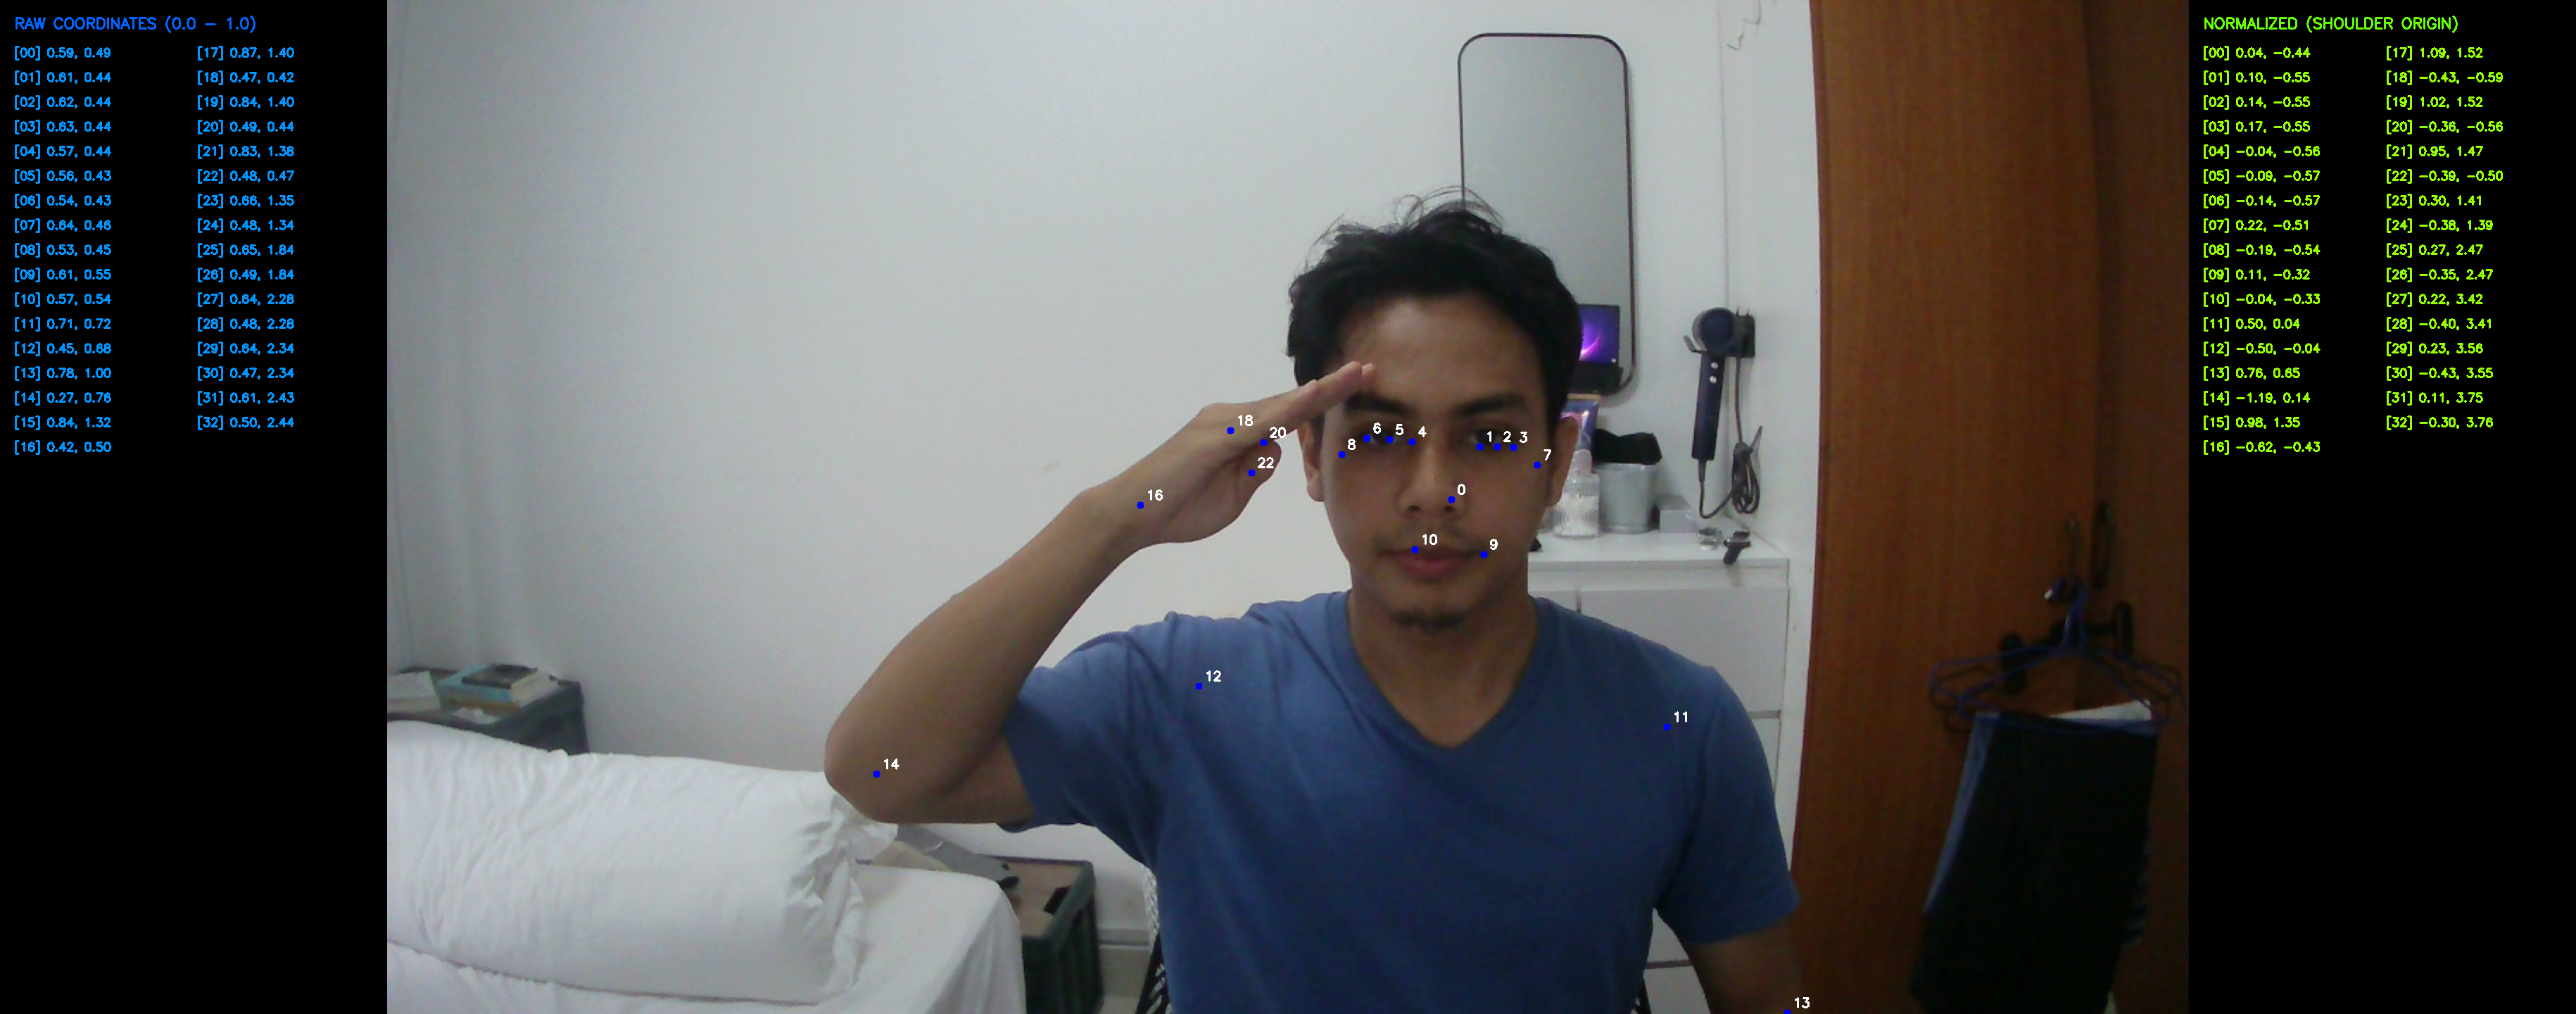

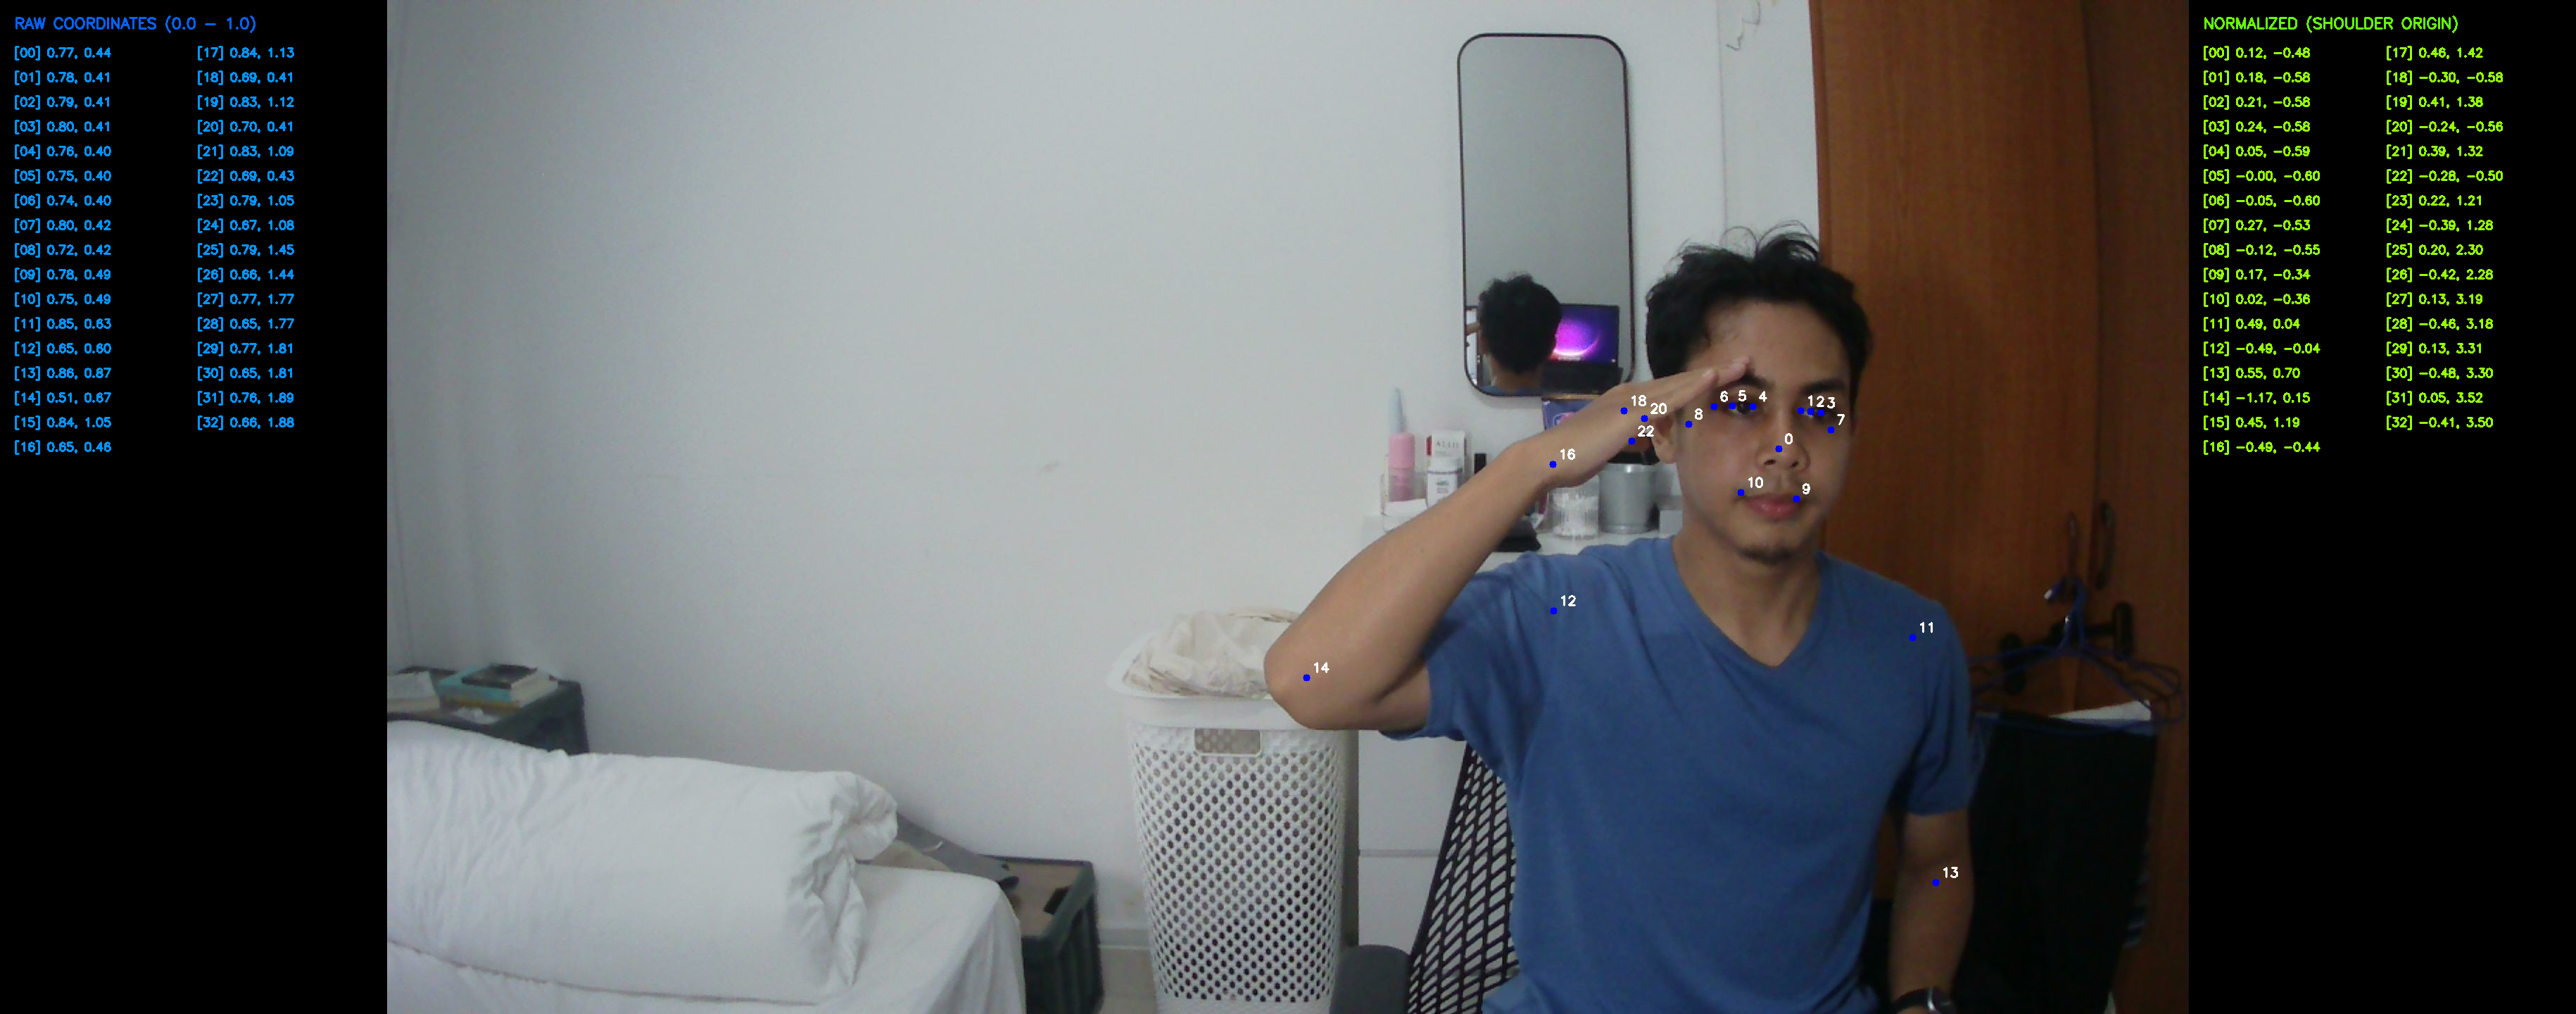

Raw Internal Change: 0.053837
Norm Internal Change: 0.035306


In [63]:
raw_results_base, norm_results_base = detect_landmark_image("/content/WIN_20260102_16_52_24_Pro.jpg",im_show=1)
raw_results_move, norm_results_move = detect_landmark_image("/content/WIN_20260102_16_52_38_Pro.jpg",im_show=1)

# Compare Nose (0) to Left Shoulder (11)
raw_dist_base = calculate_internal_dist(raw_results_base, 0, 11, True)
raw_dist_move = calculate_internal_dist(raw_results_move, 0, 11, True)

norm_dist_base = calculate_internal_dist(norm_results_base, 0, 11, False)
norm_dist_move = calculate_internal_dist(norm_results_move, 0, 11, False)

print(f"Raw Internal Change: {abs(raw_dist_base - raw_dist_move):.6f}")
print(f"Norm Internal Change: {abs(norm_dist_base - norm_dist_move):.6f}")

In [64]:

## compare only xy axis
# --- CALCULATE ---
raw_all_dist = validate_all_indices_xy(raw_results_base, raw_results_move, is_raw=True)
norm_all_dist = validate_all_indices_xy(norm_results_base, norm_results_move, is_raw=False)

# --- COMPARE RESULTS ---
print(f"Average Shift per point (Raw): {np.mean(raw_all_dist):.6f}")
print(f"Average Shift per point (Norm): {np.mean(norm_all_dist):.6f}")
print(f"Max point drift (Raw): {np.max(raw_all_dist):.6f}")
print(f"Max point drift (Norm): {np.max(norm_all_dist):.6f}")

Average Shift per point (Raw): 0.188932
Average Shift per point (Norm): 0.122056
Max point drift (Raw): 0.579510
Max point drift (Norm): 0.640003


## 4.Automated Data Collection Loop

In [ ]:
video_file = '/content/drive/MyDrive/Group_Assignment/BIM_Dataset_V3_split/trainset'
train_dataset_path = '/content/drive/MyDrive/Group_Assignment/BIM_Dataset_V3_split/trainset_landmark'
os.makedirs(train_dataset_path, exist_ok=True)

gestures_files = os.listdir(video_file)
gestures = np.array(gestures_files)
label_map = {label: num for num, label in enumerate(gestures)}

In [ ]:
[ges for ges in gestures_files if ges not in os.listdir(train_dataset_path)]

['keluarga', 'pandai', 'masalah', 'perlahan_2', 'mana', 'bahasa_isyarat']

In [ ]:
for ges in gestures:
  if ges not in os.listdir(train_dataset_path): # if already process
      print(ges)
      video_dir = os.path.join(video_file, ges)
      if not os.path.exists(video_dir):
          continue

      for vid_name in os.listdir(video_dir):
          landmark_path = os.path.join(train_dataset_path, ges, 'landmarks_' + vid_name)
          os.makedirs(landmark_path, exist_ok=True)

          video_full_path = os.path.join(video_dir, vid_name)
          cap = cv2.VideoCapture(video_full_path)
          W = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
          H = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)

          fps = cap.get(cv2.CAP_PROP_FPS)
          if fps <= 0: fps = 30

          frame_count = 0
          saved_count = 0

          with vision.PoseLandmarker.create_from_options(pose_options) as pose_landmarker, \
              vision.HandLandmarker.create_from_options(hand_options) as hand_landmarker:

              while cap.isOpened():
                  ret, frame = cap.read()

                  # Stop if video ends or we have 30 saved frames
                  if not ret or saved_count == 30:
                      break

                  # Unique, increasing timestamp starting at 0 for THIS video
                  frame_timestamp_ms = int(1000 * frame_count / fps)

                  rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                  mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)

                  try:
                      pose_res = pose_landmarker.detect_for_video(mp_image, frame_timestamp_ms)
                      hand_res = hand_landmarker.detect_for_video(mp_image, frame_timestamp_ms)

                      # Only save if hands are detected
                      if hand_res.hand_landmarks:
                          keypoints = extract_keypoints_tasks(pose_res, hand_res)
                          np.save(os.path.join(landmark_path, f"{saved_count}.npy"), keypoints)
                          saved_count += 1

                  except ValueError as e:
                      print(f"Error in {vid_name} at frame {frame_count}: {e}")
                      break

                  frame_count += 1

              cap.release()
      print(f"Gesture {ges} Finished")
      print("="*10)

print("DONE")

keluarga
Gesture keluarga Finished
pandai
Gesture pandai Finished
masalah
Gesture masalah Finished
perlahan_2
Gesture perlahan_2 Finished
mana
Gesture mana Finished
bahasa_isyarat
Gesture bahasa_isyarat Finished
DONE


## 5.Preparation for Model Training (X and y Generation)

In [ ]:
train_dataset_path = '/content/drive/MyDrive/Group_Assignment/BIM_Dataset_V3_split/trainset_landmark'

gestures_files = sorted(os.listdir(train_dataset_path))
gestures = np.array(gestures_files)
label_map = {label: num for num, label in enumerate(gestures)}
gestures

array(['abang', 'anak_lelaki', 'anak_perempuan', 'apa', 'apa_khabar',
       'assalamualaikum', 'ayah', 'bagaimana', 'bahasa_isyarat', 'baik',
       'baik_2', 'bapa_saudara', 'beli', 'beli_2', 'berapa', 'bila',
       'bomba', 'buat', 'emak', 'emak_saudara', 'hari', 'hi', 'hujan',
       'jahat', 'jangan', 'kakak', 'keluarga', 'kereta', 'lelaki',
       'lemak', 'main', 'mana', 'masalah', 'nasi', 'nasi_lemak', 'panas',
       'panas_2', 'pandai', 'pandai_2', 'payung', 'perempuan', 'perlahan',
       'perlahan_2', 'pinjam', 'polis', 'pukul', 'ribut', 'saudara',
       'sejuk', 'siapa', 'tandas'], dtype='<U15')

In [ ]:
def load_video_frames(video_path):
    """Helper function to load and sort all .npy frames in a directory."""
    files = [f for f in os.listdir(video_path) if f.endswith('.npy')]
    # Sort by numeric value in filename
    files.sort(key=lambda f: int(''.join(filter(str.isdigit, f))))

    frames = [np.load(os.path.join(video_path, f)) for f in files]
    return frames if frames else None

# 1. Collect all valid directory paths and their labels first
tasks = []
for gs in gestures:
    base_gesture_path = os.path.join(train_dataset_path, gs)
    if os.path.exists(base_gesture_path):
        for video_dir in os.listdir(base_gesture_path):
            full_path = os.path.join(base_gesture_path, video_dir)
            if os.path.isdir(full_path):
                tasks.append((full_path, label_map[gs]))

# 2. Parallel Loading (n_jobs=-1 uses all CPU cores)
print(f"Loading {len(tasks)} videos in parallel...")
results = Parallel(n_jobs=-1)(delayed(load_video_frames)(path) for path, label in tasks)

# 3. Filter out empty results and extract labels
gesture_sequence = [res for res in results if res is not None]
y = np.array([tasks[i][1] for i, res in enumerate(results) if res is not None])

# 4. Fast Padding using Keras utility
# This replaces the manual loop and handles the NumPy conversion automatically
X = pad_sequences(gesture_sequence, padding='post', dtype='float32')

print(f"Final X shape: {X.shape}")
print(f"Final y shape: {y.shape}")

# 5. Save results
np.save('X_TRAIN_preprocess.npy', X)
np.save('y_TRAIN_preprocess.npy', y)

Loading 3896 videos in parallel...


KeyboardInterrupt: 